# Klasifikasi Iris dengan MLP — Perbandingan Fungsi Aktivasi
 # Nama : Reihan Bagas Ananta
 # NIM : 4222301039

Notebook ini membandingkan performa **Multi-Layer Perceptron (MLP)** menggunakan tiga fungsi aktivasi:
- **Sigmoid**
- **Tanh**
- **ReLU**

Dataset yang digunakan adalah **Iris Dataset** dari Kaggle, yang berisi 150 sampel bunga iris dengan 3 kelas: *Setosa*, *Versicolor*, dan *Virginica*.

---

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Pengaturan tampilan plot
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")
sns.set_palette("husl")

print("library berhasil diimpor")

library berhasil diimpor


---
## 2. Load Dataset

Dataset Iris dimuat dari file `iris.csv`. Pastikan file sudah diupload ke Google Colab atau berada di direktori yang sama.

In [3]:
# Memuat dataset
df = pd.read_csv('iris.csv')

print(f"Dataset berhasil dimuat Jumlah data: {df.shape[0]} baris, {df.shape[1]} kolom")

Dataset berhasil dimuat Jumlah data: 150 baris, 6 kolom


---
## 3. Exploratory Data Analysis (EDA)

Sebelum membangun model, kita perlu memahami struktur dan karakteristik dataset terlebih dahulu.

In [4]:
# Tampilkan 5 data pertama
print("5 Data Pertama")
df.head()

5 Data Pertama


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
# Informasi umum dataset
print("Informasi Dataset")
print(df.info())

print("\nStatistik Deskriptif")
print(df.describe().round(2))

print("\nDistribusi Kelas")
print(df ['Species'].value_counts())

Informasi Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None

Statistik Deskriptif
           Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.00         150.00        150.00         150.00        150.00
mean    75.50           5.84          3.05           3.76          1.20
std     43.45           0.83          0.43           1.76          0.76
min      1.00           4.30          2.00           1.00          0.10
25%     38.25           5.10          2.80           1.60          0.30
50%  

### 3.1 Visualisasi Distribusi Fitur

Berikut distribusi setiap fitur (sepal & petal) untuk masing-masing spesies bunga.

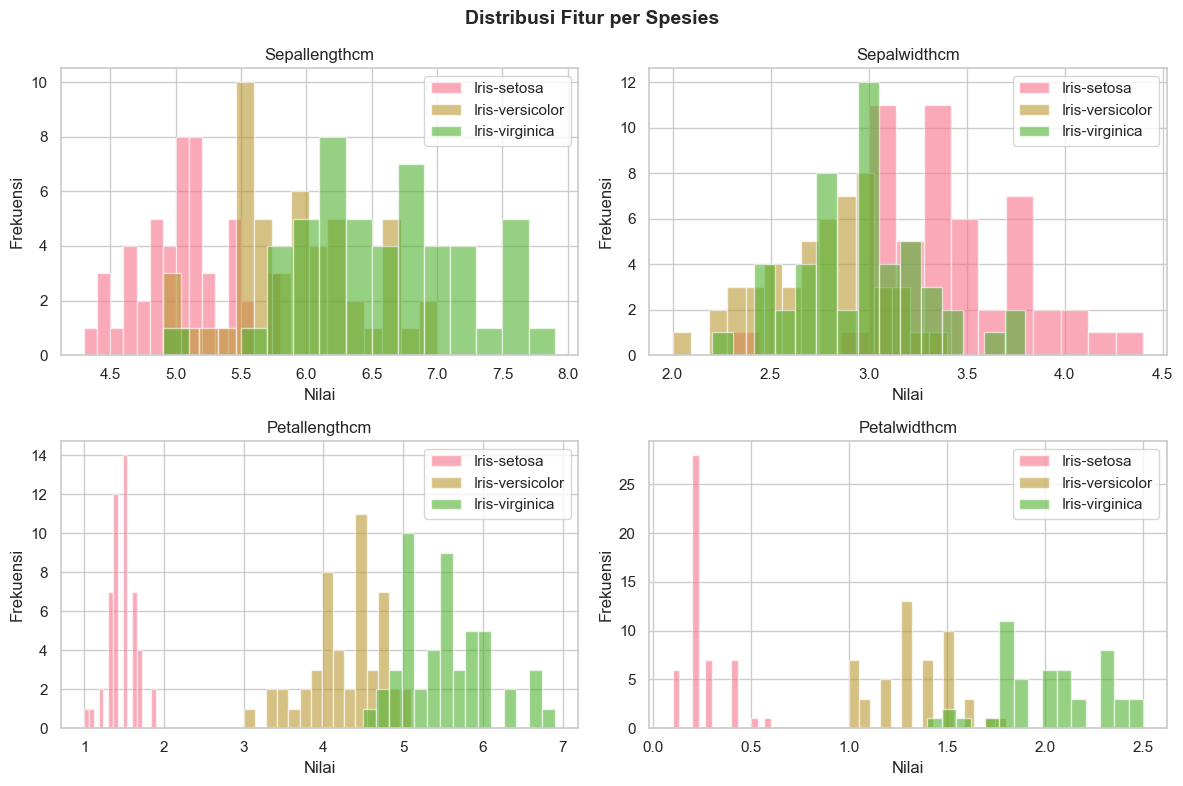

In [6]:
# Histogram distribusi setiap fitur berdasarkan spesies
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribusi Fitur per Spesies', fontsize=14, fontweight='bold')

for ax, feature in zip(axes.flatten(), features):
    for species in df['Species'].unique():
        subset = df[df['Species'] == species][feature]
        ax.hist(subset, alpha=0.6, label=species, bins=15)
    ax.set_title(feature.replace('_', ' ').title())
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Frekuensi')
    ax.legend()

plt.tight_layout()
plt.show()

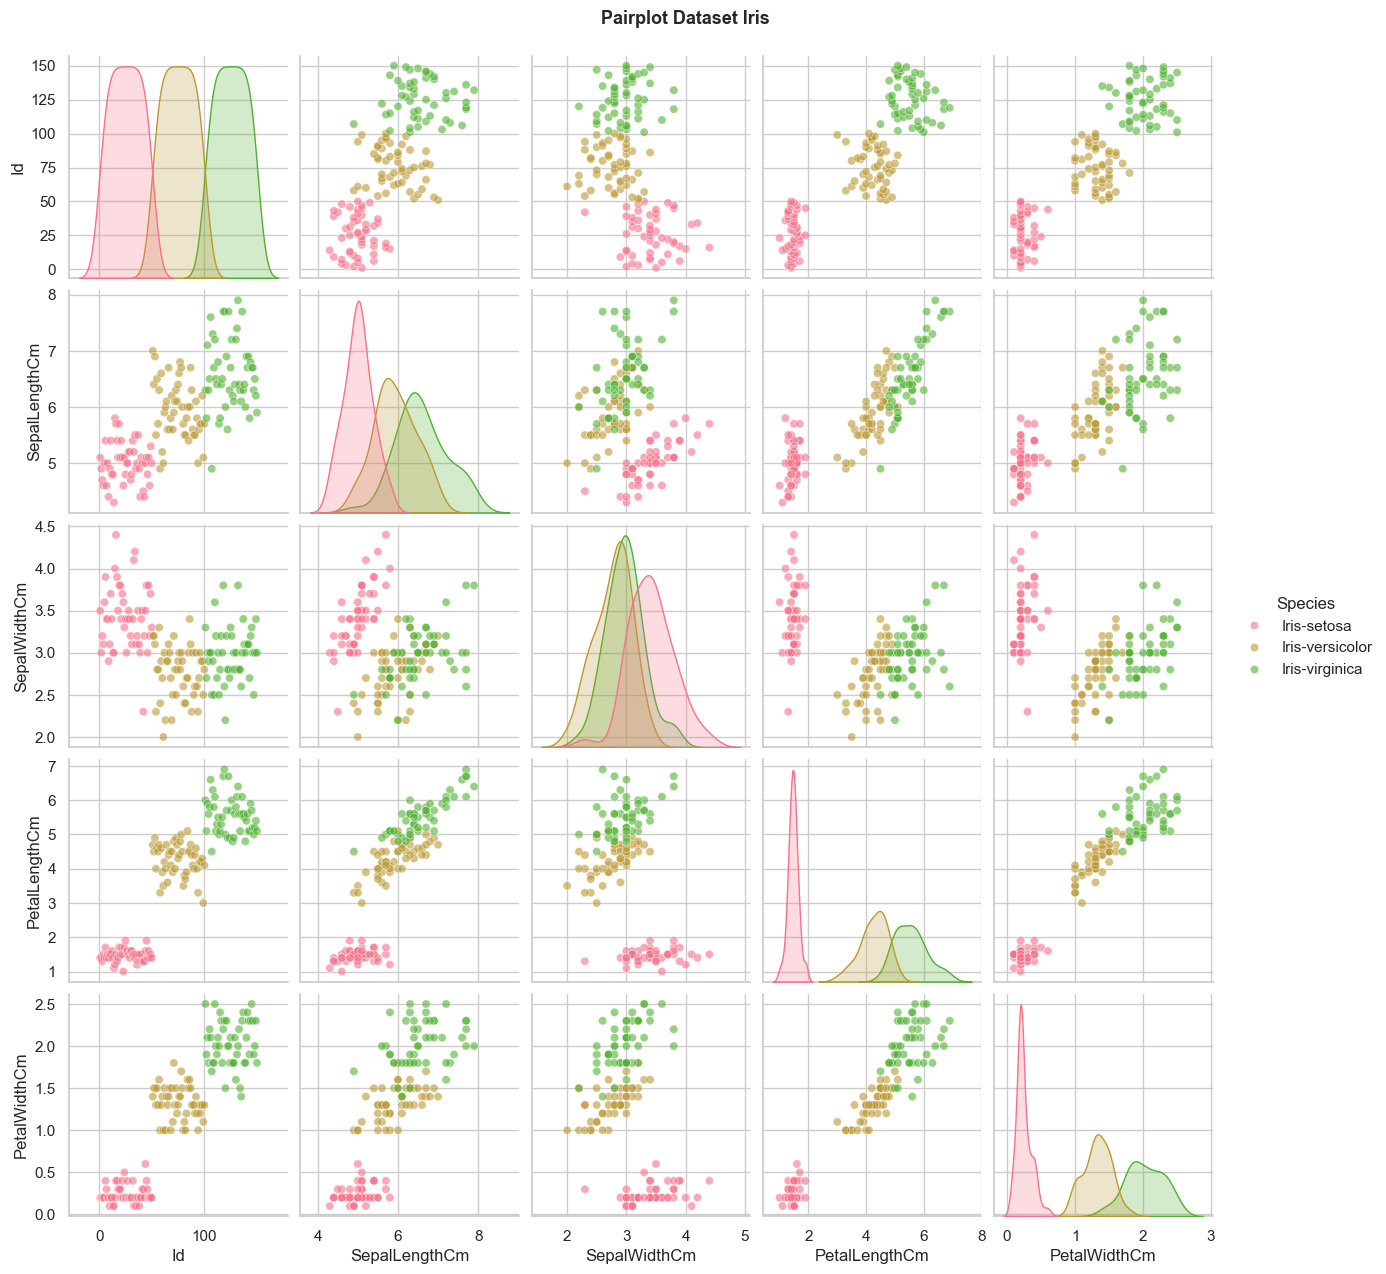

In [7]:
# Pairplot untuk melihat hubungan antar fitur
sns.pairplot(df, hue='Species', diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot Dataset Iris', y=1.02, fontsize=13, fontweight='bold')
plt.show()

---
## 4. Preprocessing Data

Langkah preprocessing meliputi:
1. **Label Encoding** — mengubah label spesies (string) menjadi angka
2. **Train-Test Split** — membagi data 70% training dan 30% testing
3. **Standardisasi** — menyamakan skala fitur agar model bekerja optimal

In [8]:
# 1. Label Encoding: setosa=0, versicolor=1, virginica=2
le = LabelEncoder()
df['species_encoded'] = le.fit_transform(df['Species'])

print("Mapping kelas:", dict(zip(le.classes_, le.transform(le.classes_))))

Mapping kelas: {'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}


In [9]:
# 2. Pisahkan fitur (X) dan target (y)
X = df[features].values
y = df['species_encoded'].values

# 3. Split data: 70% train, 30% test (stratify agar distribusi kelas seimbang)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Jumlah data training : {X_train.shape[0]} sampel")
print(f"Jumlah data testing  : {X_test.shape[0]} sampel")

Jumlah data training : 105 sampel
Jumlah data testing  : 45 sampel


In [10]:
# 4. Standardisasi: fit hanya pada training, transform keduanya
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("Standardisasi selesai. Mean fitur training ≈", X_train.mean(axis=0).round(3))

Standardisasi selesai. Mean fitur training ≈ [ 0. -0. -0.  0.]


---
## 5. Membangun & Melatih Model MLP

Model MLP dibangun dengan arsitektur yang sama untuk ketiga fungsi aktivasi:
- Hidden layers: **64 → 32 neuron**
- Optimizer: **Adam**
- Max iterasi: **3000** (dengan early stopping)

Hanya fungsi aktivasi yang berbeda antara ketiga model.

In [11]:
def latih_dan_evaluasi(nama, aktivasi, ax=None):
    """
    Melatih model MLP dengan fungsi aktivasi tertentu,
    lalu mengembalikan hasil evaluasinya.
    """
    print(f"\n>>> Melatih model dengan aktivasi: {nama}...")

    model = MLPClassifier(
        hidden_layer_sizes=(64, 32),   # Arsitektur: 2 hidden layer
        activation=aktivasi,           # Fungsi aktivasi yang diuji
        solver='adam',                 # Optimizer Adam
        alpha=1e-4,                    # Regularisasi L2
        batch_size=16,
        learning_rate='adaptive',
        learning_rate_init=0.005,
        max_iter=3000,
        early_stopping=True,           # Berhenti jika tidak ada peningkatan
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    akurasi   = accuracy_score(y_test, y_pred)
    laporan   = classification_report(y_test, y_pred, target_names=le.classes_)
    loss_akhir = model.loss_curve_[-1]

    print(f"    Akurasi  : {akurasi * 100:.2f}%")
    print(f"    Iterasi  : {model.n_iter_}")
    print(f"    Loss akhir: {loss_akhir:.4f}")

    # Plot kurva loss ke subplot yang diberikan
    if ax is not None:
        ax.plot(model.loss_curve_, label=f'{nama} (loss={loss_akhir:.4f})')
        ax.set_title('Kurva Training Loss')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend()
        ax.grid(True)

    return {
        'Fungsi Aktivasi': nama,
        'Akurasi'        : akurasi,
        'Iterasi'        : model.n_iter_,
        'Loss Akhir'     : loss_akhir,
        'model'          : model,
        'y_pred'         : y_pred,
        'laporan'        : laporan
    }


>>> Melatih model dengan aktivasi: Sigmoid...
    Akurasi  : 91.11%
    Iterasi  : 49
    Loss akhir: 0.0472

>>> Melatih model dengan aktivasi: Tanh...
    Akurasi  : 86.67%
    Iterasi  : 28
    Loss akhir: 0.0317

>>> Melatih model dengan aktivasi: ReLU...
    Akurasi  : 86.67%
    Iterasi  : 30
    Loss akhir: 0.0190


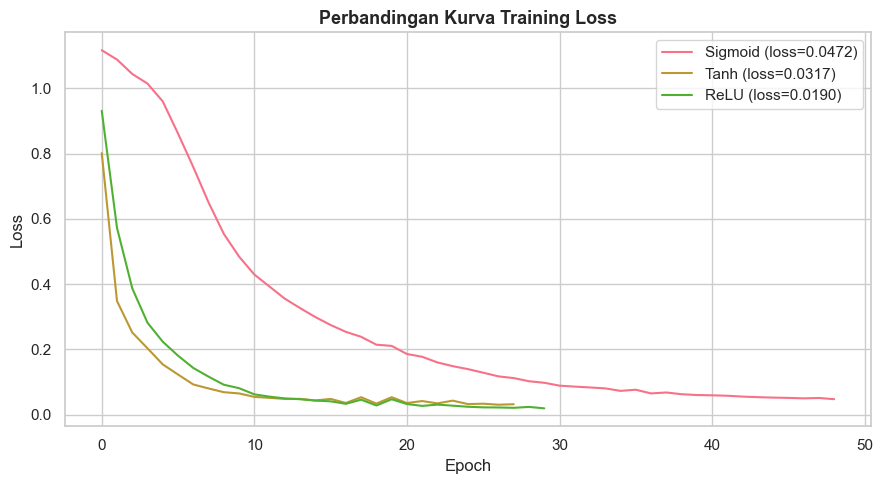

In [12]:
# Jalankan ketiga model sekaligus, kurva loss ditampilkan dalam satu grafik
fig, ax = plt.subplots(figsize=(9, 5))

hasil_sigmoid = latih_dan_evaluasi('Sigmoid', 'logistic', ax)
hasil_tanh    = latih_dan_evaluasi('Tanh',    'tanh',     ax)
hasil_relu    = latih_dan_evaluasi('ReLU',    'relu',     ax)

ax.set_title('Perbandingan Kurva Training Loss', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

semua_hasil = [hasil_sigmoid, hasil_tanh, hasil_relu]

---
## 6. Confusion Matrix

Confusion matrix menunjukkan secara detail kesalahan prediksi setiap model untuk masing-masing kelas.

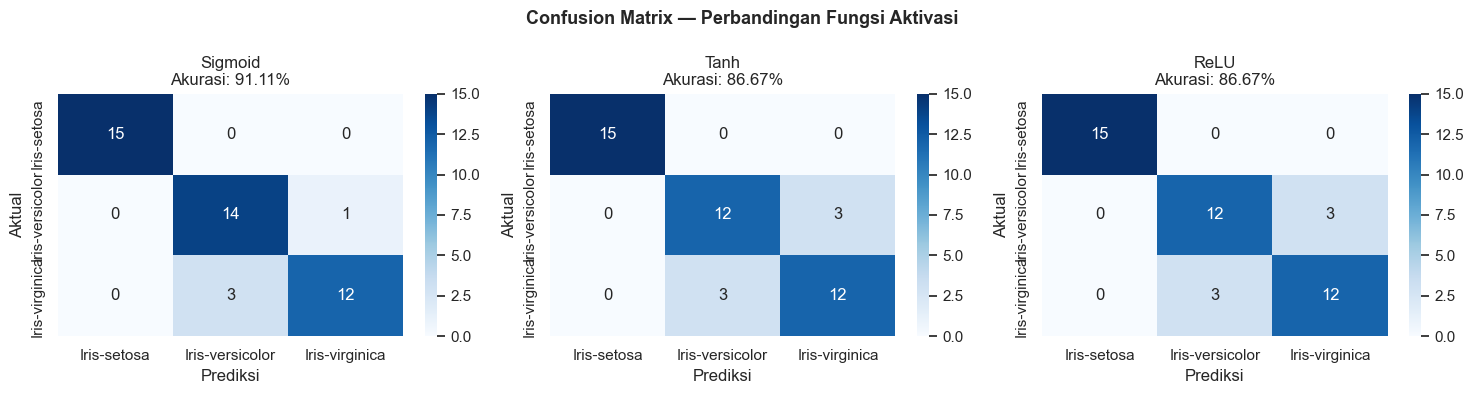

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrix — Perbandingan Fungsi Aktivasi', fontsize=13, fontweight='bold')

for ax, hasil in zip(axes, semua_hasil):
    cm = confusion_matrix(y_test, hasil['y_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=le.classes_, yticklabels=le.classes_, ax=ax
    )
    ax.set_title(f"{hasil['Fungsi Aktivasi']}\nAkurasi: {hasil['Akurasi']*100:.2f}%")
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

plt.tight_layout()
plt.show()

---
## 7. Laporan Klasifikasi

Laporan ini menampilkan **precision**, **recall**, dan **F1-score** untuk setiap kelas pada masing-masing model.

In [14]:
for hasil in semua_hasil:
    print(f"{'='*50}")
    print(f" Laporan Klasifikasi — Aktivasi: {hasil['Fungsi Aktivasi']}")
    print(f"{'='*50}")
    print(hasil['laporan'])

 Laporan Klasifikasi — Aktivasi: Sigmoid
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.82      0.93      0.88        15
 Iris-virginica       0.92      0.80      0.86        15

       accuracy                           0.91        45
      macro avg       0.92      0.91      0.91        45
   weighted avg       0.92      0.91      0.91        45

 Laporan Klasifikasi — Aktivasi: Tanh
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.80      0.80      0.80        15
 Iris-virginica       0.80      0.80      0.80        15

       accuracy                           0.87        45
      macro avg       0.87      0.87      0.87        45
   weighted avg       0.87      0.87      0.87        45

 Laporan Klasifikasi — Aktivasi: ReLU
                 precision    recall  f1-score   support

    Iris-setosa      

---
## 8. Tabel Perbandingan Performa

Berikut ringkasan performa ketiga model dalam satu tabel untuk memudahkan perbandingan.

In [15]:
# Buat dataframe perbandingan
tabel = pd.DataFrame([{
    'Fungsi Aktivasi': h['Fungsi Aktivasi'],
    'Akurasi'        : h['Akurasi'],
    'Iterasi'        : h['Iterasi'],
    'Loss Akhir'     : h['Loss Akhir']
} for h in semua_hasil])

print("Tabel Perbandingan Performa MLP:")
try:
    display(
        tabel.style
        .format({'Akurasi': '{:.2%}', 'Loss Akhir': '{:.4f}'})
        .background_gradient(cmap='YlGnBu', subset=['Akurasi', 'Loss Akhir'])
        .set_caption('Ringkasan Hasil Eksperimen MLP — Dataset Iris')
        .highlight_max(subset=['Akurasi'], color='#c6efce')  # Hijau = akurasi tertinggi
        .highlight_min(subset=['Loss Akhir'], color='#c6efce')  # Hijau = loss terendah
    )
except Exception as e:
    print("Style table gagal karena:", e)
    display(tabel)

Tabel Perbandingan Performa MLP:
Style table gagal karena: The '.style' accessor requires jinja2


,Fungsi Aktivasi,Akurasi,Iterasi,Loss Akhir
0,Sigmoid,0.911111,49,0.047163
1,Tanh,0.866667,28,0.031675
2,ReLU,0.866667,30,0.019031


---
## 9. Kesimpulan & Rekomendasi

### Hasil Perbandingan

| Fungsi Aktivasi | Akurasi | Iterasi | Loss Akhir | Keterangan |
|:---:|:---:|:---:|:---:|:---|
| **Sigmoid** | **91.11%** | 49 | 0.0472 | Akurasi tertinggi |
| Tanh | 86.67% | 28 | 0.0317 | Konvergen lebih cepat |
| ReLU | 86.67% | 30 | **0.0190** | Loss paling rendah |

### Analisis per Kelas (dari Confusion Matrix)

- **Semua model** berhasil mengklasifikasi kelas **Setosa** dengan sempurna (100%)
- **Sigmoid** paling baik membedakan kelas **Versicolor** dan **Virginica** (hanya 1 kesalahan)
- **Tanh & ReLU** memiliki performa serupa — masing-masing membuat 3 kesalahan pada Versicolor dan Virginica

### Fungsi Aktivasi Terbaik: **Sigmoid**

Sigmoid unggul dengan akurasi **91.11%** untuk dataset Iris ini. Hal ini kemungkinan karena:
- Dataset Iris berukuran kecil (150 sampel) dengan fitur yang sudah ternormalisasi
- Sigmoid bekerja baik pada data berskala kecil karena outputnya terbatas di rentang (0, 1)
- Masalah vanishing gradient pada Sigmoid tidak terlalu berpengaruh di jaringan yang dangkal

### Rekomendasi Penggunaan

| Kondisi | Pilihan |
|:---|:---:|
| Prioritas akurasi tertinggi | **Sigmoid** |
| Prioritas efisiensi & loss rendah | **ReLU** |
| Keseimbangan kecepatan & akurasi | **Tanh** |